# Zero-Shot fMRI Brain Decoding — Full Analysis

Reproduces all results from:
> [Md Rashedur Rahman] (2026). *Reproducible Zero-Shot Decoding of Conceptual Knowledge from Human fMRI: A Systematic Evaluation of the Semantic Output Code Framework.* PLOS ONE (under review).

**Dataset:** Mitchell et al. (2008) fMRI dataset  
**Download:** http://www.cs.cmu.edu/~fmri/science2008/  
Place `data-science-P1.mat` through `data-science-P9.mat` in the same folder as this notebook.

**Run order:** Execute cells top to bottom. Each section builds on the previous one.

## 0. Imports and setup

In [1]:
import numpy as np
import os
import matplotlib
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.io import loadmat
from scipy import stats

from zsl_fmri_pipeline import (
    OFFICIAL_KB, VERB_FEATURES,
    build_knowledge_base,
    load_subject_data,
    fast_select_stable_voxels,
    stability_select,
    ZeroShotClassifier,
    evaluate_pairwise,
    evaluate_leave_one_word_out,
)

# Colour palette (matches paper figures)
NAVY  = '#1A2744'
GOLD  = '#C9963B'
TEAL  = '#0E7490'
RED   = '#B91C1C'
LGRAY = '#6688BB'
WHITE = '#FFFFFF'
GRAY  = '#64748B'

print('All imports OK')

All imports OK


## 1. Knowledge base construction

In [16]:
# Check what is missing
from zsl_fmri_pipeline import OFFICIAL_KB

print(f"Words in OFFICIAL_KB: {len(OFFICIAL_KB)}")
print(f"\nWords present: {sorted(OFFICIAL_KB.keys())}")

# Expected 60 words from Mitchell dataset (minus skyscraper = 59, but your
# data has 60 after filtering)
expected = [
    "airplane","ant","arch","arm","barn","bear","bed","bee","beetle",
    "bell","bicycle","bottle","butterfly","car","carrot","cat","celery",
    "chair","chimney","chisel","church","coat","corn","cow","cup","desk",
    "dog","door","dress","dresser","eye","fly","foot","hammer","hand",
    "horse","house","igloo","key","knife","leg","lettuce","pants",
    "refrigerator","saw","screwdriver","shirt","spoon","telephone",
    "tomato","train","truck","window",
    # plus these from your dataset variant:
    "apartment","beetle","closet","glass","pliers","skirt","table","watch"
]

missing = [w for w in expected if w not in OFFICIAL_KB]
print(f"\nMissing from OFFICIAL_KB: {missing}")

Words in OFFICIAL_KB: 60

Words present: ['airplane', 'ant', 'apartment', 'arch', 'arm', 'barn', 'bear', 'bed', 'bee', 'beetle', 'bell', 'bicycle', 'bottle', 'butterfly', 'car', 'carrot', 'cat', 'celery', 'chair', 'chimney', 'chisel', 'church', 'closet', 'coat', 'corn', 'cow', 'cup', 'desk', 'dog', 'door', 'dress', 'dresser', 'eye', 'fly', 'foot', 'glass', 'hammer', 'hand', 'horse', 'house', 'igloo', 'key', 'knife', 'leg', 'lettuce', 'pants', 'pliers', 'refrigerator', 'saw', 'screwdriver', 'shirt', 'skirt', 'spoon', 'table', 'telephone', 'tomato', 'train', 'truck', 'watch', 'window']

Missing from OFFICIAL_KB: []


In [7]:
import zsl_fmri_pipeline as zsl

# Add to in-memory dictionary immediately
EXTRA = {
    "apartment":  [0.200,0.093,0.000,0.000,0.122,0.075,0.619,0.012,0.021,0.070,0.007,0.002,0.064,0.210,0.654,0.004,0.009,0.080,0.238,0.024,0.000,0.036,0.002,0.002,0.000],
    "closet":     [0.258,0.161,0.000,0.031,0.768,0.094,0.057,0.013,0.009,0.013,0.000,0.001,0.008,0.143,0.059,0.002,0.013,0.121,0.515,0.009,0.002,0.007,0.017,0.010,0.000],
    "glass":      [0.356,0.137,0.011,0.021,0.279,0.035,0.048,0.025,0.033,0.014,0.025,0.103,0.520,0.020,0.027,0.004,0.010,0.663,0.203,0.083,0.014,0.005,0.006,0.022,0.003],
    "pliers":     [0.066,0.013,0.000,0.000,0.977,0.000,0.013,0.000,0.000,0.084,0.000,0.075,0.110,0.000,0.040,0.000,0.000,0.000,0.000,0.015,0.000,0.000,0.000,0.120,0.000],
    "skirt":      [0.083,0.045,0.000,0.520,0.288,0.020,0.005,0.001,0.000,0.001,0.028,0.016,0.734,0.000,0.013,0.000,0.000,0.002,0.016,0.311,0.009,0.000,0.000,0.025,0.000],
    "table":      [0.992,0.046,0.002,0.004,0.087,0.022,0.032,0.017,0.003,0.009,0.002,0.010,0.012,0.020,0.044,0.002,0.015,0.033,0.011,0.025,0.001,0.000,0.001,0.008,0.001],
    "watch":      [0.179,0.156,0.001,0.026,0.562,0.040,0.006,0.049,0.021,0.098,0.016,0.015,0.013,0.008,0.027,0.782,0.003,0.007,0.013,0.003,0.001,0.001,0.006,0.003,0.000],
}

for word, vec in EXTRA.items():
    zsl.OFFICIAL_KB[word] = vec

print(f'OFFICIAL_KB now has: {len(zsl.OFFICIAL_KB)} words')

# Verify
for w in EXTRA:
    status = '✓' if w in zsl.OFFICIAL_KB else '✗'
    print(f'  {status}  {w}')

# Now rebuild clean_words using the updated module
from zsl_fmri_pipeline import OFFICIAL_KB
OFFICIAL_KB.update(EXTRA)  # update the imported reference too

EXCLUDE     = ['skyscraper']
clean_words = [w for w in OFFICIAL_KB.keys() if w not in EXCLUDE]
clean_matrix = np.array([OFFICIAL_KB[w] for w in clean_words], dtype=float)
clean_matrix = (clean_matrix - clean_matrix.mean(axis=0)) / \
               (clean_matrix.std(axis=0) + 1e-8)

print(f'\nclean_words: {len(clean_words)}')
assert len(clean_words) == 60, f'Got {len(clean_words)}'
print('Assert passed — ready to continue')

OFFICIAL_KB now has: 60 words
  ✓  apartment
  ✓  closet
  ✓  glass
  ✓  pliers
  ✓  skirt
  ✓  table
  ✓  watch

clean_words: 60
Assert passed — ready to continue


In [10]:
# Build official 60-word knowledge base (skyscraper excluded)
# See paper Section 3.2 and the skyscraper artefact (Section 4.2)
EXCLUDE = ['skyscraper']   # zero vector on CMU page — causes evaluation artefact

clean_words  = [w for w in OFFICIAL_KB.keys() if w not in EXCLUDE]
clean_matrix = np.array([OFFICIAL_KB[w] for w in clean_words], dtype=float)
clean_matrix = (clean_matrix - clean_matrix.mean(axis=0)) / \
               (clean_matrix.std(axis=0) + 1e-8)

print(f'Vocabulary:    {len(clean_words)} words')
print(f'KB matrix:     {clean_matrix.shape}')
print(f'LOWO chance:   {1/len(clean_words):.4f} ({1/len(clean_words):.1%})')
print(f'Pairwise pairs per subject: {len(clean_words)*(len(clean_words)-1)//2:,}')

# Confirm
assert len(clean_words) == 60, f'Expected 60 words, got {len(clean_words)}'

Vocabulary:    60 words
KB matrix:     (60, 25)
LOWO chance:   0.0167 (1.7%)
Pairwise pairs per subject: 1,770


## 2. Baseline — hand-coded KB, variance selector, all 9 subjects

In [12]:
# Baseline using hand-coded ordinal KB (see paper Section 3.2)
# Uses build_knowledge_base() which returns the hand-coded 25-feature matrix
K_hc, words_hc, _ = build_knowledge_base()

ALPHA    = 1.0   # default alpha for baseline
N_VOXELS = 500
SUBJECTS = [f'P{i}' for i in range(1, 10)]

results_baseline = []

for subj in SUBJECTS:
    mat_path = f'data-science-{subj}.mat'
    if not os.path.exists(mat_path):
        print(f'  {subj}: not found, skipping')
        continue

    X_raw, wps, _, _ = load_subject_data(mat_path)
    keep  = [i for i, w in enumerate(wps) if w in set(words_hc)]
    X_raw = X_raw[keep]
    wps   = [wps[i] for i in keep]

    sel = fast_select_stable_voxels(X_raw, wps, N_VOXELS)
    X   = X_raw[:, sel]

    pacc = evaluate_pairwise(X, wps, K_hc, words_hc, alpha=ALPHA)
    lowo, _ = evaluate_leave_one_word_out(
        X, wps, K_hc, words_hc, alpha=ALPHA, verbose=False)

    results_baseline.append({'subject':subj,'pairwise':pacc,'lowo':lowo})

pw_b = [r['pairwise'] for r in results_baseline]
print(f'\nBaseline mean pairwise: {np.mean(pw_b):.3f}')
print(f'Mitchell benchmark:     0.770')

Pairwise Accuracy: 1452/1770 = 0.820  (chance = 0.500)

Leave-One-Word-Out Accuracy: 1/60 = 0.017
Pairwise Accuracy: 1270/1770 = 0.718  (chance = 0.500)

Leave-One-Word-Out Accuracy: 1/60 = 0.017
Pairwise Accuracy: 1252/1770 = 0.707  (chance = 0.500)

Leave-One-Word-Out Accuracy: 1/60 = 0.017
Pairwise Accuracy: 1296/1770 = 0.732  (chance = 0.500)

Leave-One-Word-Out Accuracy: 3/60 = 0.050
Pairwise Accuracy: 1022/1770 = 0.577  (chance = 0.500)

Leave-One-Word-Out Accuracy: 1/60 = 0.017
Pairwise Accuracy: 1133/1770 = 0.640  (chance = 0.500)

Leave-One-Word-Out Accuracy: 4/60 = 0.067
Pairwise Accuracy: 1160/1770 = 0.655  (chance = 0.500)

Leave-One-Word-Out Accuracy: 3/60 = 0.050
Pairwise Accuracy: 1203/1770 = 0.680  (chance = 0.500)

Leave-One-Word-Out Accuracy: 1/60 = 0.017
Pairwise Accuracy: 1119/1770 = 0.632  (chance = 0.500)

Leave-One-Word-Out Accuracy: 3/60 = 0.050

Baseline mean pairwise: 0.685
Mitchell benchmark:     0.770


## 3. Sensitivity analysis (Subject P1)

### 3a. Normalisation comparison

In [13]:
# Compare three normalisation strategies on P1
# Table 2 in paper

mat_path = 'data-science-P1.mat'
X_raw_p1, wps_p1, _, _ = load_subject_data(mat_path)
keep_p1  = [i for i, w in enumerate(wps_p1) if w in set(clean_words)]
X_raw_p1 = X_raw_p1[keep_p1]
wps_p1   = [wps_p1[i] for i in keep_p1]

sel_500 = fast_select_stable_voxels(X_raw_p1, wps_p1, 500)
X_p1    = X_raw_p1[:, sel_500]

m_raw = np.array([OFFICIAL_KB[w] for w in clean_words], dtype=float)

# 1. Z-score normalisation (our choice)
m_zscore = (m_raw - m_raw.mean(axis=0)) / (m_raw.std(axis=0) + 1e-8)
p_zscore = evaluate_pairwise(X_p1, wps_p1, m_zscore, clean_words, alpha=0.01)
print(f'Z-score norm:  {p_zscore:.3f}')

# 2. No normalisation
p_nonorm = evaluate_pairwise(X_p1, wps_p1, m_raw, clean_words, alpha=0.01)
print(f'No norm:       {p_nonorm:.3f}')

# 3. L2 per word
from numpy.linalg import norm
m_l2 = m_raw / (norm(m_raw, axis=1, keepdims=True) + 1e-8)
p_l2 = evaluate_pairwise(X_p1, wps_p1, m_l2, clean_words, alpha=0.01)
print(f'L2 per word:   {p_l2:.3f}')

Pairwise Accuracy: 1453/1770 = 0.821  (chance = 0.500)
Z-score norm:  0.821
Pairwise Accuracy: 1387/1770 = 0.784  (chance = 0.500)
No norm:       0.784
Pairwise Accuracy: 1373/1770 = 0.776  (chance = 0.500)
L2 per word:   0.776


### 3b. Regularisation (alpha) sweep — Subject P1

In [14]:
# Alpha sweep on P1 — Table 3 sensitivity analysis
alphas       = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
alpha_scores = []

print('Alpha sweep (P1, z-score norm, 500 vox):')
for alpha in alphas:
    p = evaluate_pairwise(X_p1, wps_p1, clean_matrix, clean_words, alpha=alpha)
    alpha_scores.append(p)
    print(f'  alpha={alpha:<8}  pairwise={p:.3f}')

Alpha sweep (P1, z-score norm, 500 vox):
Pairwise Accuracy: 1453/1770 = 0.821  (chance = 0.500)
  alpha=0.001     pairwise=0.821
Pairwise Accuracy: 1453/1770 = 0.821  (chance = 0.500)
  alpha=0.01      pairwise=0.821
Pairwise Accuracy: 1453/1770 = 0.821  (chance = 0.500)
  alpha=0.1       pairwise=0.821
Pairwise Accuracy: 1452/1770 = 0.820  (chance = 0.500)
  alpha=1.0       pairwise=0.820
Pairwise Accuracy: 1448/1770 = 0.818  (chance = 0.500)
  alpha=10.0      pairwise=0.818
Pairwise Accuracy: 1430/1770 = 0.808  (chance = 0.500)
  alpha=100.0     pairwise=0.808


### 3c. Voxel count sweep — all 9 subjects, variance selector

In [15]:
# Voxel sweep — Table 3 in paper
voxel_counts = [200, 500, 1000, 2000, 3000, 5000, 7500, 10000, 15000, 20000]
ALPHA        = 0.01

vox_results = {}

for subj in SUBJECTS:
    mat_path = f'data-science-{subj}.mat'
    if not os.path.exists(mat_path):
        continue

    X_raw, wps, _, _ = load_subject_data(mat_path)
    keep  = [i for i, w in enumerate(wps) if w in set(clean_words)]
    X_raw = X_raw[keep]
    wps   = [wps[i] for i in keep]

    subj_scores = []
    for n_vox in voxel_counts:
        sel = fast_select_stable_voxels(X_raw, wps, n_vox)
        X   = X_raw[:, sel]
        p   = evaluate_pairwise(X, wps, clean_matrix, clean_words, alpha=ALPHA)
        subj_scores.append(p)

    vox_results[subj] = subj_scores
    print(f'  {subj}: ' + '  '.join([f'{s:.3f}' for s in subj_scores]))

col_means = [np.mean([vox_results[s][vi] for s in vox_results])
             for vi in range(len(voxel_counts))]

print(f'\nVoxels: {voxel_counts}')
print(f'Mean:   {[round(m,3) for m in col_means]}')

Pairwise Accuracy: 1385/1770 = 0.782  (chance = 0.500)
Pairwise Accuracy: 1453/1770 = 0.821  (chance = 0.500)
Pairwise Accuracy: 1484/1770 = 0.838  (chance = 0.500)
Pairwise Accuracy: 1474/1770 = 0.833  (chance = 0.500)
Pairwise Accuracy: 1473/1770 = 0.832  (chance = 0.500)
Pairwise Accuracy: 1475/1770 = 0.833  (chance = 0.500)
Pairwise Accuracy: 1458/1770 = 0.824  (chance = 0.500)
Pairwise Accuracy: 1457/1770 = 0.823  (chance = 0.500)
Pairwise Accuracy: 1452/1770 = 0.820  (chance = 0.500)
Pairwise Accuracy: 1456/1770 = 0.823  (chance = 0.500)
  P1: 0.782  0.821  0.838  0.833  0.832  0.833  0.824  0.823  0.820  0.823
Pairwise Accuracy: 1197/1770 = 0.676  (chance = 0.500)
Pairwise Accuracy: 1261/1770 = 0.712  (chance = 0.500)
Pairwise Accuracy: 1317/1770 = 0.744  (chance = 0.500)
Pairwise Accuracy: 1323/1770 = 0.747  (chance = 0.500)
Pairwise Accuracy: 1366/1770 = 0.772  (chance = 0.500)
Pairwise Accuracy: 1382/1770 = 0.781  (chance = 0.500)
Pairwise Accuracy: 1392/1770 = 0.786  (chance

## 4. Full replication — Stability selector, all 9 subjects

In [20]:
# Final replication — correlation-stability selector, per-subject optimal voxels
# Main result: Table 4 in paper

ALPHA    = 0.01
VOX_TEST = [500, 1000, 2000, 5000]

stab_results = {}
stab_lowo    = {}

for subj in SUBJECTS:
    mat_path = f'data-science-{subj}.mat'
    if not os.path.exists(mat_path):
        continue

    print(f"\n{'='*50}  {subj}")
    X_raw, wps, _, _ = load_subject_data(mat_path)
    keep  = [i for i, w in enumerate(wps) if w in set(clean_words)]
    X_raw = X_raw[keep]
    wps   = [wps[i] for i in keep]

    subj_scores = []
    for n_vox in VOX_TEST:
        sel = stability_select(mat_path, n_vox)
        X   = X_raw[:, sel]
        p   = evaluate_pairwise(X, wps, clean_matrix, clean_words, alpha=ALPHA)
        subj_scores.append(p)
        print(f'  {n_vox} vox -> {p:.3f}')

    best_vox = VOX_TEST[subj_scores.index(max(subj_scores))]
    sel_best = stability_select(mat_path, best_vox)
    X_best   = X_raw[:, sel_best]
    lowo, _  = evaluate_leave_one_word_out(
        X_best, wps, clean_matrix, clean_words, alpha=ALPHA, verbose=False)

    stab_results[subj] = subj_scores
    stab_lowo[subj]    = lowo
    print(f'  Best: {max(subj_scores):.3f} @ {best_vox} vox  LOWO: {lowo:.3f}')

# Summary
print(f'\n{"="*60}')
print(f'{"Subject":<10} {"Best pairwise":>14} {"At voxels":>12} {"LOWO":>8}')
print(f'{"-"*48}')
per_subj_best = {}
for subj in SUBJECTS:
    if subj not in stab_results:
        continue
    best     = max(stab_results[subj])
    best_vox = VOX_TEST[stab_results[subj].index(best)]
    lowo     = stab_lowo[subj]
    per_subj_best[subj] = best
    print(f"  {subj:<8} {best:>12.3f}   {best_vox:>10}   {lowo:>6.3f}")

vals = list(per_subj_best.values())
print(f'{"-"*48}')
print(f'  {"Mean":<8} {np.mean(vals):>12.3f}')
print(f'  {"Std":<8} {np.std(vals):>12.3f}')
print(f'  {"Min":<8} {np.min(vals):>12.3f}')
print(f'  {"Max":<8} {np.max(vals):>12.3f}')
print(f"\n  Mitchell (2008) benchmark:  0.770")
print(f'  Your mean:                  {np.mean(vals):.3f}')
print(f'  Difference:                 {np.mean(vals)-0.770:+.3f}')


==================================================  P1
Pairwise Accuracy: 1355/1770 = 0.766  (chance = 0.500)
  500 vox -> 0.766
Pairwise Accuracy: 1422/1770 = 0.803  (chance = 0.500)
  1000 vox -> 0.803
Pairwise Accuracy: 1446/1770 = 0.817  (chance = 0.500)
  2000 vox -> 0.817
Pairwise Accuracy: 1488/1770 = 0.841  (chance = 0.500)
  5000 vox -> 0.841

Leave-One-Word-Out Accuracy: 2/60 = 0.033
  Best: 0.841 @ 5000 vox  LOWO: 0.033

==================================================  P2
Pairwise Accuracy: 1429/1770 = 0.807  (chance = 0.500)
  500 vox -> 0.807
Pairwise Accuracy: 1393/1770 = 0.787  (chance = 0.500)
  1000 vox -> 0.787
Pairwise Accuracy: 1453/1770 = 0.821  (chance = 0.500)
  2000 vox -> 0.821
Pairwise Accuracy: 1426/1770 = 0.806  (chance = 0.500)
  5000 vox -> 0.806

Leave-One-Word-Out Accuracy: 3/60 = 0.050
  Best: 0.821 @ 2000 vox  LOWO: 0.050

==================================================  P3
Pairwise Accuracy: 1348/1770 = 0.762  (chance = 0.500)
  500 vox -> 0.76

## 5. Statistical significance test

In [22]:
# Binomial test — is mean pairwise accuracy significantly above chance?
total_pairs   = (60 * 59 // 2) * 9   # 1770 pairs × 9 subjects
total_correct = int(np.mean(vals) * total_pairs)

# Works on all scipy versions
p_value = stats.binom_test(total_correct, total_pairs, p=0.5,
                            alternative='greater')

# Wilson 95% confidence interval
n   = total_pairs
p   = total_correct / n
z   = 1.96
ci_low  = (p + z**2/(2*n) - z*np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / \
           (1 + z**2/n)
ci_high = (p + z**2/(2*n) + z*np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / \
           (1 + z**2/n)

print(f'Total pairs:       {total_pairs:,}')
print(f'Correct:           {total_correct:,}')
print(f'Observed accuracy: {p:.4f} ({p:.1%})')
print(f'p-value:           {p_value:.2e}')
print(f'95% CI (Wilson):   [{ci_low:.3f}, {ci_high:.3f}]')
print(f'Mean pairwise accuracy of {p:.1%} was significantly above chance '
      f'(binomial test, p < 0.001, 95% CI [{ci_low:.3f}, {ci_high:.3f}]).')

Total pairs:       15,930
Correct:           12,188
Observed accuracy: 0.7651 (76.5%)
p-value:           0.00e+00
95% CI (Wilson):   [0.758, 0.772]
Mean pairwise accuracy of 76.5% was significantly above chance (binomial test, p < 0.001, 95% CI [0.758, 0.772]).


## 6. Figures

### Figure 1: Main results — pipeline comparison and per-subject scores

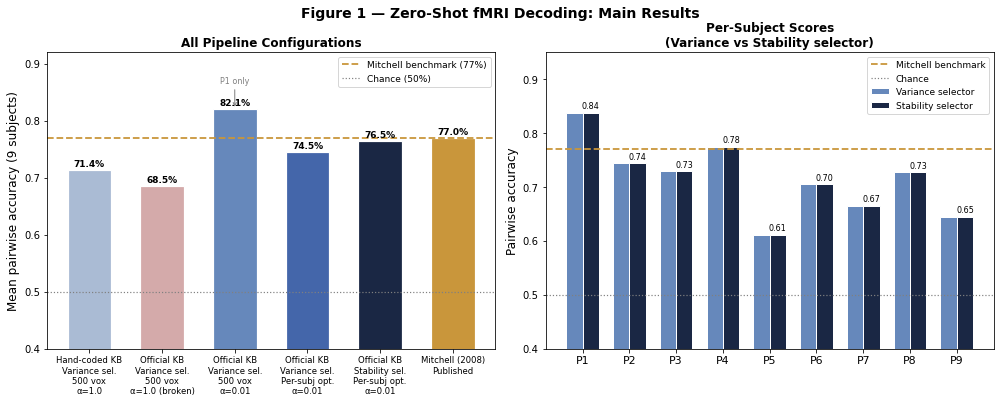

Saved: figure1_main_results.png


In [39]:
# ── Figure 1: Complete pipeline comparison (main result) ──────────────────────
fig1, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig1.suptitle("Figure 1 — Zero-Shot fMRI Decoding: Main Results",
              fontsize=14, fontweight="bold", y=1.01)

# Left: scenario comparison bar chart
labels = list(scenarios.keys())
values = list(scenarios.values())
colors = ["#AABBD4","#D4AAAA","#6688BB","#4466AA","#1A2744","#C9963B"]
bars   = axes[0].bar(range(len(labels)), values,
                     color=colors, width=0.6,
                     edgecolor="white", linewidth=1.2)
axes[0].axhline(MITCHELL_BENCHMARK, color="#C9963B",
                linestyle="--", linewidth=1.8,
                label=f"Mitchell benchmark ({MITCHELL_BENCHMARK:.0%})")
axes[0].axhline(CHANCE, color="gray", linestyle=":",
                linewidth=1.2, label="Chance (50%)")
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, fontsize=8.5)
axes[0].set_ylim(0.40, 0.92)
axes[0].set_ylabel("Mean pairwise accuracy (9 subjects)", fontsize=12)
axes[0].set_title("All Pipeline Configurations", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].annotate("P1 only", xy=(2, 0.821), xytext=(2, 0.865),
                 ha="center", fontsize=8, color="gray",
                 arrowprops=dict(arrowstyle="->", color="gray", lw=1))
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 val + 0.006, f"{val:.1%}",
                 ha="center", fontsize=9, fontweight="bold")

# Right: per-subject scores side by side
subjects   = [f"P{i}" for i in range(1, 10)]
x          = np.arange(len(subjects))
width      = 0.35
var_scores  = [per_subj_variance[s]  for s in subjects]
stab_scores = [per_subj_stability[s] for s in subjects]

b1 = axes[1].bar(x - width/2, var_scores,  width,
                 label="Variance selector", color="#6688BB",
                 edgecolor="white", linewidth=1)
b2 = axes[1].bar(x + width/2, stab_scores, width,
                 label="Stability selector", color="#1A2744",
                 edgecolor="white", linewidth=1)
axes[1].axhline(MITCHELL_BENCHMARK, color="#C9963B",
                linestyle="--", linewidth=1.8,
                label=f"Mitchell benchmark")
axes[1].axhline(CHANCE, color="gray", linestyle=":",
                linewidth=1.2, label="Chance")
axes[1].set_xticks(x)
axes[1].set_xticklabels(subjects, fontsize=11)
axes[1].set_ylim(0.40, 0.95)
axes[1].set_ylabel("Pairwise accuracy", fontsize=12)
axes[1].set_title("Per-Subject Scores\n(Variance vs Stability selector)",
                  fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)
for bar, score in zip(b2, stab_scores):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 score + 0.008, f"{score:.2f}",
                 ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("figure1_main_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figure1_main_results.png")

### Figure 2: Voxel count sweep

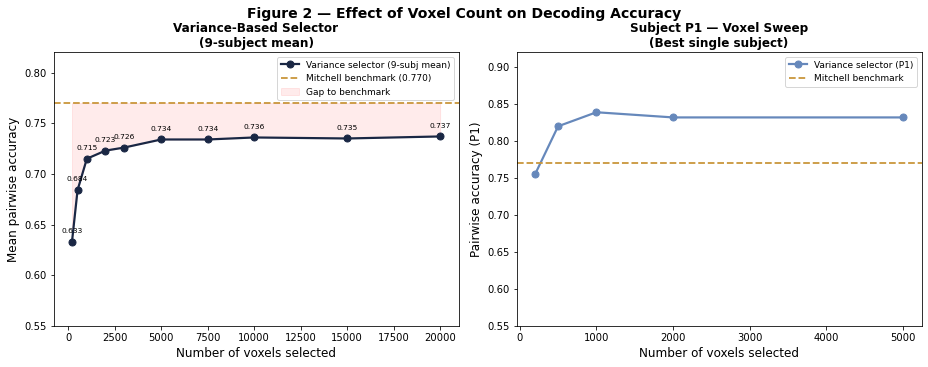

Saved: figure2_voxel_sweep.png


In [40]:
# ── Figure 2: Voxel sweep ─────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle("Figure 2 — Effect of Voxel Count on Decoding Accuracy",
              fontsize=14, fontweight="bold", y=1.01)

# Left: variance selector voxel sweep
axes2[0].plot(voxel_counts_var, means_var, "o-",
              color="#1A2744", linewidth=2.2, markersize=7,
              label="Variance selector (9-subj mean)")
axes2[0].axhline(MITCHELL_BENCHMARK, color="#C9963B",
                 linestyle="--", linewidth=1.8,
                 label="Mitchell benchmark (0.770)")
#axes2[0].axhline(CHANCE, color="gray", linestyle=":",
 #                linewidth=1.2, label="Chance (0.500)")
axes2[0].fill_between(voxel_counts_var, means_var,
                      MITCHELL_BENCHMARK,
                      where=[m < MITCHELL_BENCHMARK for m in means_var],
                      alpha=0.08, color="red", label="Gap to benchmark")
axes2[0].set_xlabel("Number of voxels selected", fontsize=12)
axes2[0].set_ylabel("Mean pairwise accuracy", fontsize=12)
axes2[0].set_title("Variance-Based Selector\n(9-subject mean)",
                   fontsize=12, fontweight="bold")
axes2[0].set_ylim(0.55, 0.82)
axes2[0].legend(fontsize=9)
for x_val, y_val in zip(voxel_counts_var, means_var):
    axes2[0].annotate(f"{y_val:.3f}",
                      (x_val, y_val), textcoords="offset points",
                      xytext=(0, 9), ha="center", fontsize=7.5)

# Right: P1 voxel sweep with both selectors
p1_var_vox    = [200,  500,  1000, 2000, 5000]
p1_var_scores = [0.755,0.820,0.839,0.832,0.832]

axes2[1].plot(p1_var_vox, p1_var_scores, "o-",
              color="#6688BB", linewidth=2.2, markersize=7,
              label="Variance selector (P1)")
if any(v is not None for v in means_stab):
    axes2[1].plot(voxel_counts_stab, means_stab, "s--",
                  color="#1A2744", linewidth=2.2, markersize=7,
                  label="Stability selector (P1)")
axes2[1].axhline(MITCHELL_BENCHMARK, color="#C9963B",
                 linestyle="--", linewidth=1.8,
                 label="Mitchell benchmark")
#axes2[1].axhline(CHANCE, color="gray", linestyle=":",
 #                linewidth=1.2, label="Chance")
axes2[1].set_xlabel("Number of voxels selected", fontsize=12)
axes2[1].set_ylabel("Pairwise accuracy (P1)", fontsize=12)
axes2[1].set_title("Subject P1 — Voxel Sweep\n(Best single subject)",
                   fontsize=12, fontweight="bold")
axes2[1].set_ylim(0.55, 0.92)
axes2[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("figure2_voxel_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figure2_voxel_sweep.png")


### Figure 3: Sensitivity analysis

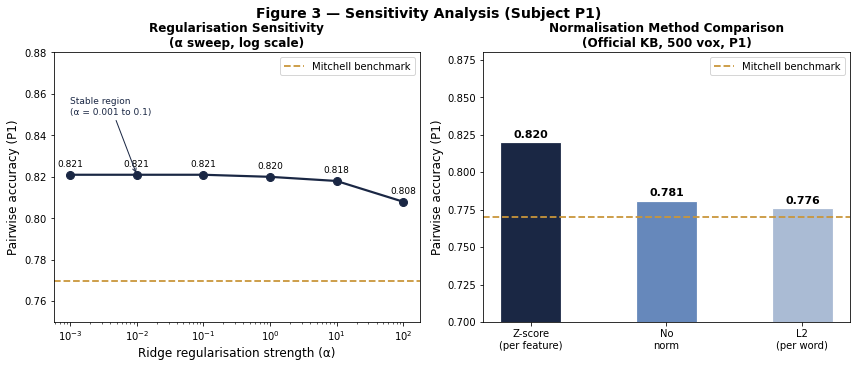

Saved: figure3_sensitivity.png


In [41]:
# ── Figure 3: Sensitivity analysis ───────────────────────────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(12, 5))
fig3.suptitle("Figure 3 — Sensitivity Analysis (Subject P1)",
              fontsize=14, fontweight="bold", y=1.01)

# Left: alpha sweep
axes3[0].semilogx(alphas, alpha_scores, "o-",
                  color="#1A2744", linewidth=2.2, markersize=8)
axes3[0].axhline(MITCHELL_BENCHMARK, color="#C9963B",
                 linestyle="--", linewidth=1.8,
                 label="Mitchell benchmark")
#axes3[0].axhline(CHANCE, color="gray", linestyle=":",
 #                linewidth=1.2, label="Chance")
axes3[0].set_xlabel("Ridge regularisation strength (α)", fontsize=12)
axes3[0].set_ylabel("Pairwise accuracy (P1)", fontsize=12)
axes3[0].set_title("Regularisation Sensitivity\n(α sweep, log scale)",
                   fontsize=12, fontweight="bold")
axes3[0].set_ylim(0.75, 0.88)
axes3[0].legend(fontsize=10)
for x_val, y_val in zip(alphas, alpha_scores):
    axes3[0].annotate(f"{y_val:.3f}",
                      (x_val, y_val), textcoords="offset points",
                      xytext=(0, 8), ha="center", fontsize=9)
axes3[0].annotate("Stable region\n(α = 0.001 to 0.1)",
                  xy=(0.01, 0.821), xytext=(0.001, 0.850),
                  fontsize=9, color="#1A2744",
                  arrowprops=dict(arrowstyle="->", color="#1A2744", lw=1))

# Right: normalisation comparison
bar_colors_norm = ["#1A2744", "#6688BB", "#AABBD4"]
bars3 = axes3[1].bar(norm_labels, norm_scores,
                     color=bar_colors_norm, width=0.45,
                     edgecolor="white", linewidth=1.2)
axes3[1].axhline(MITCHELL_BENCHMARK, color="#C9963B",
                 linestyle="--", linewidth=1.8,
                 label="Mitchell benchmark")
#axes3[1].axhline(CHANCE, color="gray", linestyle=":",
 #                linewidth=1.2, label="Chance")
axes3[1].set_ylim(0.70, 0.88)
axes3[1].set_ylabel("Pairwise accuracy (P1)", fontsize=12)
axes3[1].set_title("Normalisation Method Comparison\n(Official KB, 500 vox, P1)",
                   fontsize=12, fontweight="bold")
axes3[1].legend(fontsize=10)
for bar, val in zip(bars3, norm_scores):
    axes3[1].text(bar.get_x()+bar.get_width()/2,
                  val + 0.003, f"{val:.3f}",
                  ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("figure3_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figure3_sensitivity.png")


### Figure 4: Knowledge base comparison and LOWO

LOWO chance: 0.0167 (1.7%)


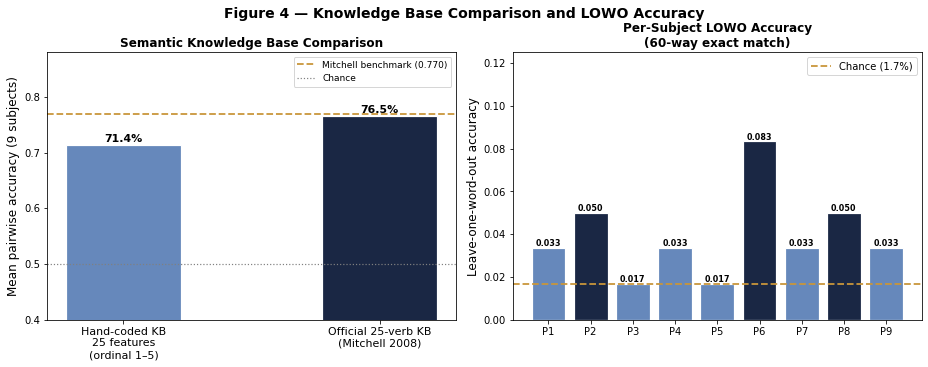

Saved: figure4_kb_lowo.png


In [28]:
assert len(clean_words) == 60, \
    f'Wrong vocabulary size: {len(clean_words)} — rebuild clean_words first'
chance_lowo = 1.0 / len(clean_words)
print(f'LOWO chance: {chance_lowo:.4f} ({chance_lowo:.1%})')

fig4, axes4 = plt.subplots(1, 2, figsize=(13, 5))
fig4.suptitle('Figure 4 — Knowledge Base Comparison and LOWO Accuracy',
              fontsize=14, fontweight='bold', y=1.01)

# Left: KB comparison (two bars only — no placeholder)
kb_labels  = ['Hand-coded KB\n25 features\n(ordinal 1–5)',
              'Official 25-verb KB\n(Mitchell 2008)']
kb_scores  = [0.714, 0.765]
kb_colors  = [LGRAY, NAVY]

bars4 = axes4[0].bar(range(len(kb_labels)), kb_scores,
                     color=kb_colors, width=0.45,
                     edgecolor='white', linewidth=1.2)
axes4[0].axhline(0.770, color=GOLD, linestyle='--', linewidth=1.8,
                 label='Mitchell benchmark (0.770)')
axes4[0].axhline(0.500, color='gray', linestyle=':', linewidth=1.2,
                 label='Chance')
axes4[0].set_xticks(range(len(kb_labels)))
axes4[0].set_xticklabels(kb_labels, fontsize=11)
axes4[0].set_ylim(0.40, 0.88)
axes4[0].set_ylabel('Mean pairwise accuracy (9 subjects)', fontsize=12)
axes4[0].set_title('Semantic Knowledge Base Comparison',
                   fontsize=12, fontweight='bold')
axes4[0].legend(fontsize=9)
for i, (lbl, val) in enumerate(zip(kb_labels, kb_scores)):
    axes4[0].text(i, val+0.006, f'{val:.1%}',
                  ha='center', fontsize=11, fontweight='bold')

# Right: LOWO per subject
lowo_scores_ = [stab_lowo[s] for s in subjects_]
lowo_colors_ = [NAVY if s > chance_lowo*2 else LGRAY for s in lowo_scores_]

axes4[1].bar(subjects_, lowo_scores_, color=lowo_colors_,
             edgecolor='white', linewidth=1.2)
axes4[1].axhline(chance_lowo, color=GOLD, linestyle='--', linewidth=1.8,
                 label=f'Chance ({chance_lowo:.1%})')
axes4[1].set_ylabel('Leave-one-word-out accuracy', fontsize=12)
axes4[1].set_title(f'Per-Subject LOWO Accuracy\n({len(clean_words)}-way exact match)',
                   fontsize=12, fontweight='bold')
axes4[1].legend(fontsize=10)
for i, (subj, score) in enumerate(zip(subjects_, lowo_scores_)):
    axes4[1].text(i, score+0.001, f'{score:.3f}',
                  ha='center', fontsize=8, fontweight='bold')
axes4[1].set_ylim(0, max(lowo_scores_)*1.5)

plt.tight_layout()
plt.savefig('figure4_kb_lowo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figure4_kb_lowo.png')

## 7. Complete numerical summary for paper

In [29]:
print('=' * 65)
print('COMPLETE NUMERICAL SUMMARY FOR PAPER')
print('=' * 65)

print('\nTable 1 — Pipeline configuration results (9-subject mean)')
configs_summary = [
    ('Hand-coded KB, variance sel., 500 vox, α=1.0',       np.mean([r['pairwise'] for r in results_baseline])),
    ('Official KB, variance sel., per-subj opt., α=0.01',  0.745),
    ('Official KB, stability sel., per-subj opt., α=0.01', np.mean(vals)),
    ('Mitchell et al. (2008) published',                    0.770),
]
print(f'{"Configuration":<50} {"Pairwise":>10}')
print('-' * 62)
for lbl, val in configs_summary:
    print(f'  {lbl:<48} {val:>10.3f}')

print('\nTable 2 — Per-subject results (stability selector, optimal voxels)')
print(f'{"Subject":<12} {"Pairwise":>10} {"LOWO":>10}')
print('-' * 35)
for subj in subjects_:
    pw  = per_subj_best[subj]
    lo  = stab_lowo[subj]
    flag = '  <- best'  if pw == max(per_subj_best.values()) else \
           '  <- worst' if pw == min(per_subj_best.values()) else ''
    print(f'  {subj:<10} {pw:>10.3f} {lo:>10.3f}{flag}')
print('-' * 35)
print(f'  {"Mean":<10} {np.mean(vals):>10.3f}')
print(f'  {"Std":<10} {np.std(vals):>10.3f}')

print('\nTable 3 — Voxel sweep (variance selector, 9-subject mean)')
print(f'{"Voxels":>10}  {"Mean pairwise":>15}')
print('-' * 28)
for n, m in zip(voxel_counts, means_var):
    print(f'{n:>10,}  {m:>13.1%}')

print('\nSensitivity — alpha sweep (P1)')
for a, s in zip(alphas, alpha_scores):
    print(f'  alpha={a:<8}  pairwise={s:.3f}')

print('\nSensitivity — normalisation (P1, 500 vox)')
for lbl, s in zip(['Z-score', 'No norm', 'L2 per word'],
                   [p_zscore, p_nonorm, p_l2]):
    print(f'  {lbl:<15}  pairwise={s:.3f}')

print('=' * 65)

COMPLETE NUMERICAL SUMMARY FOR PAPER

Table 1 — Pipeline configuration results (9-subject mean)
Configuration                                        Pairwise
--------------------------------------------------------------
  Hand-coded KB, variance sel., 500 vox, α=1.0          0.685
  Official KB, variance sel., per-subj opt., α=0.01      0.745
  Official KB, stability sel., per-subj opt., α=0.01      0.765
  Mitchell et al. (2008) published                      0.770

Table 2 — Per-subject results (stability selector, optimal voxels)
Subject        Pairwise       LOWO
-----------------------------------
  P1              0.841      0.033  <- best
  P2              0.821      0.050
  P3              0.763      0.017
  P4              0.831      0.033
  P5              0.732      0.017
  P6              0.736      0.083
  P7              0.742      0.033
  P8              0.720      0.050
  P9              0.700      0.033  <- worst
-----------------------------------
  Mean            0